# EfficientNetB0 Training Notebook (PSM)

This notebook mirrors the MobileNetV2 and MobileNetV3 workflow and adapts it for EfficientNetB0.


## Goals
- Train an EfficientNetB0 CNN model for palm fruit ripeness classification.
- Keep directory conventions, output artifacts, and evaluation protocol identical to the MobileNetV2/V3 notebooks for fair comparison.
- Export FP32 / FP16 / INT8 TFLite artifacts directly from the live in-memory model to avoid Keras 3 H5 deserialization issues.


## Key differences from MobileNetV2/V3
- Backbone: `tf.keras.applications.EfficientNetB0` (compound-scaled, ~5.3M params)
- Preprocessing: `efficientnet.preprocess_input` — scales `[0, 255]` to `[-1, 1]`
- No internal preprocessing layer (unlike MobileNetV3) — single preprocessing source enforced in the dataset pipeline
- Separate experiment log: `reports/experiment_log_efficientnetb0.csv`
- `PREPROCESS_FAMILY = "efficientnet"` is now supported in `scripts/pi_inference.py` and `scripts/convert_tflite.py` for runtime deployment


In [1]:
import os
import json
import random
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_input_efficientnet

# ---------------- Configuration ----------------
DATASET_ROOT = Path(os.getenv("DATASET_ROOT", r"C:\Users\jeffy\Documents\PSM\Dataset1"))
TRAIN_ROOT   = Path(os.getenv("TRAIN_ROOT",   str(DATASET_ROOT / "Train")))
TEST_ROOT    = Path(os.getenv("TEST_ROOT",    str(DATASET_ROOT / "Test")))

SAVED_MODELS_DIR     = Path(os.getenv("MODEL_DIR",    "saved_models"))
REPORTS_DIR          = Path(os.getenv("REPORTS_DIR",  "reports"))
EXPERIMENT_LOG_PATH  = REPORTS_DIR / "experiment_log_efficientnetb0.csv"

IMG_SIZE   = (224, 224)    # EfficientNetB0 default input; keep fixed for fair comparison
BATCH_SIZE = 32
VAL_SPLIT  = 0.2
SEED       = 42

USE_IMAGENET          = True
DO_SMOKE              = False   # Set True for a quick 1-epoch pipeline check
DO_FINE_TUNE          = True    # Set True to fine-tune top backbone layers after warm-up
EPOCHS                = 30
FINE_TUNE_EPOCHS      = 15
INITIAL_LR            = 1e-4
FINE_TUNE_LR          = 1e-5
FINE_TUNE_UNFREEZE_LAYERS = 30  # Unfreeze last N layers during fine-tune phase

MODEL_NAME        = "EfficientNetB0"
PREPROCESS_FAMILY = "efficientnet"
# NOTE: EfficientNetB0 has NO internal preprocessing layer option.
# Preprocessing is applied exclusively in the dataset pipeline (single source).

TIMESTAMP             = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
BEST_MODEL_PATH       = SAVED_MODELS_DIR / f"palm_ripeness_best_{TIMESTAMP}.h5"
FINAL_MODEL_PATH      = SAVED_MODELS_DIR / f"palm_ripeness_final_{TIMESTAMP}.h5"
FINETUNED_MODEL_PATH  = SAVED_MODELS_DIR / f"palm_ripeness_finetuned_{TIMESTAMP}.h5"

CONFUSION_MATRIX_PATH       = REPORTS_DIR / f"confusion_matrix_{TIMESTAMP}.png"
CLASSIFICATION_METRICS_PATH = REPORTS_DIR / f"classification_metrics_{TIMESTAMP}.png"
CLASSIFICATION_REPORT_XLSX  = REPORTS_DIR / f"classification_report_{TIMESTAMP}.xlsx"

for directory in [SAVED_MODELS_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

autotune = tf.data.AUTOTUNE

print("TensorFlow:", tf.__version__)
print("Model:", MODEL_NAME)
print("Preprocess family:", PREPROCESS_FAMILY)
print("Dataset root:", DATASET_ROOT)
print("Train root:", TRAIN_ROOT)
print("Test root:", TEST_ROOT)
print("Output model dir:", SAVED_MODELS_DIR)
print("Output reports dir:", REPORTS_DIR)
print("Best model path:", BEST_MODEL_PATH)
print("GPU available:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
Model: EfficientNetB0
Preprocess family: efficientnet
Dataset root: C:\Users\jeffy\Documents\PSM\Dataset1
Train root: C:\Users\jeffy\Documents\PSM\Dataset1\Train
Test root: C:\Users\jeffy\Documents\PSM\Dataset1\Test
Output model dir: saved_models
Output reports dir: reports
Best model path: saved_models\palm_ripeness_best_20260423_160250.h5
GPU available: []


## Data Contract Checks
Verify dataset directories exist and class folders match between train and test splits.

In [2]:
def list_class_names(root: Path):
    return sorted([p.name for p in root.iterdir() if p.is_dir()])

def count_images(root: Path):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sum(1 for p in root.rglob("*") if p.is_file() and p.suffix.lower() in exts)

if not TRAIN_ROOT.exists():
    raise FileNotFoundError(f"Train directory not found: {TRAIN_ROOT}")
if not TEST_ROOT.exists():
    raise FileNotFoundError(f"Test directory not found: {TEST_ROOT}")

CLASS_NAMES      = list_class_names(TRAIN_ROOT)
TEST_CLASS_NAMES = list_class_names(TEST_ROOT)

if not CLASS_NAMES:
    raise ValueError(f"No class folders found under train root: {TRAIN_ROOT}")
if CLASS_NAMES != TEST_CLASS_NAMES:
    raise ValueError(
        f"Train/Test class folders do not match. Train={CLASS_NAMES}, Test={TEST_CLASS_NAMES}"
    )

NUM_CLASSES        = len(CLASS_NAMES)
TRAIN_IMAGE_COUNT  = count_images(TRAIN_ROOT)
TEST_IMAGE_COUNT   = count_images(TEST_ROOT)

print("Classes:", CLASS_NAMES)
print("Num classes:", NUM_CLASSES)
print("Train images:", TRAIN_IMAGE_COUNT)
print("Test images:", TEST_IMAGE_COUNT)


Classes: ['Overripe', 'Ripe', 'Underripe']
Num classes: 3
Train images: 1200
Test images: 180


## Dataset Loading
Load raw image datasets with train/val split. Test set is never seen during training.

In [3]:
train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_ROOT,
    labels="inferred",
    label_mode="categorical",
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_ROOT,
    labels="inferred",
    label_mode="categorical",
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_ROOT,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

if train_ds_raw.class_names != CLASS_NAMES:
    raise ValueError(
        f"Class order mismatch. expected={CLASS_NAMES}, got={train_ds_raw.class_names}"
    )

if DO_SMOKE:
    train_ds_raw = train_ds_raw.take(2)
    val_ds_raw   = val_ds_raw.take(1)
    test_ds_raw  = test_ds_raw.take(1)

print("Train batches:", tf.data.experimental.cardinality(train_ds_raw).numpy())
print("Val batches:",   tf.data.experimental.cardinality(val_ds_raw).numpy())
print("Test batches:",  tf.data.experimental.cardinality(test_ds_raw).numpy())
print("Class names:", train_ds_raw.class_names)


Found 1200 files belonging to 3 classes.
Using 960 files for training.
Found 1200 files belonging to 3 classes.
Using 240 files for validation.
Found 180 files belonging to 3 classes.
Train batches: 30
Val batches: 8
Test batches: 6
Class names: ['Overripe', 'Ripe', 'Underripe']


## Preprocessing and Augmentation

EfficientNetB0 uses `efficientnet.preprocess_input` which scales `[0, 255]` → `[-1, 1]`.

**Single preprocessing source rule**: EfficientNetB0 has no internal preprocessing layer,
so the dataset pipeline is the only preprocessing point. This avoids the double-preprocessing
issue encountered with MobileNetV3.


In [4]:
def apply_preprocess(x: tf.Tensor) -> tf.Tensor:
    """Apply model-family-specific preprocessing.
    EfficientNet expects float32 input in [-1, 1] range.
    preprocess_input handles the [0,255] -> [-1,1] scaling.
    """
    x = tf.cast(x, tf.float32)
    if PREPROCESS_FAMILY == "efficientnet":
        return preprocess_input_efficientnet(x)
    raise ValueError(f"Unsupported PREPROCESS_FAMILY={PREPROCESS_FAMILY}")


def preprocess_xy(x, y):
    return apply_preprocess(x), y


train_ds = (
    train_ds_raw
    .map(preprocess_xy, num_parallel_calls=autotune)
    .apply(tf.data.experimental.ignore_errors())
    .prefetch(autotune)
)
val_ds = (
    val_ds_raw
    .map(preprocess_xy, num_parallel_calls=autotune)
    .apply(tf.data.experimental.ignore_errors())
    .prefetch(autotune)
)
test_ds = (
    test_ds_raw
    .map(preprocess_xy, num_parallel_calls=autotune)
    .apply(tf.data.experimental.ignore_errors())
    .prefetch(autotune)
)

# Augmentation — active only during training, skipped at inference
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.15),
        tf.keras.layers.RandomZoom(0.10),
    ],
    name="data_augmentation",
)

print("Preprocessing family:", PREPROCESS_FAMILY)
print("Augmentation: RandomFlip, RandomRotation(0.15), RandomZoom(0.10)")
print("Single preprocessing source: dataset pipeline only (no internal backbone layer)")


Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.
Preprocessing family: efficientnet
Augmentation: RandomFlip, RandomRotation(0.15), RandomZoom(0.10)
Single preprocessing source: dataset pipeline only (no internal backbone layer)


## Build Model

EfficientNetB0 backbone with identical classification head to MobileNetV2/V3 for fair comparison:
- GlobalAveragePooling2D
- Dropout(0.30)
- Dense(128, relu)
- BatchNormalization
- Dropout(0.20)
- Dense(num_classes, softmax)


In [5]:
input_tensor = tf.keras.Input(shape=(*IMG_SIZE, 3), name="image")
x = data_augmentation(input_tensor)

base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights="imagenet" if USE_IMAGENET else None,
)

# Freeze all backbone layers for warm-up phase
base_model.trainable = False

x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.20)(x)
output_tensor = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="ripeness_probs")(x)

model = tf.keras.Model(input_tensor, output_tensor, name="PalmRipeness_EfficientNetB0")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()
print(f"\nTotal trainable params: {sum(tf.size(v).numpy() for v in model.trainable_variables):,}")
print(f"Total params: {model.count_params():,}")
print(f"Backbone layers: {len(base_model.layers)}")


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "PalmRipeness_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ripeness_probs (Dense)          │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,438 (16.08 MB)

 Trainable params: 164,611 (643.01 KB)

 Non-trainable params: 4,049,827 (15.45 MB)


Total trainable params: 164,611
Total params: 4,214,438
Backbone layers: 238


## Callbacks

In [6]:
monitor_metric = "val_loss"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor=monitor_metric,
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor=monitor_metric,
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor=monitor_metric,
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
]

print("Callbacks ready.")
print("Best checkpoint will be saved to:", BEST_MODEL_PATH)
print("Monitor metric:", monitor_metric)


Callbacks ready.
Best checkpoint will be saved to: saved_models\palm_ripeness_best_20260423_160250.h5
Monitor metric: val_loss


## Phase 1: Warm-up Training (Frozen Backbone)

Train only the classification head with the EfficientNetB0 backbone frozen.
This lets the head converge to reasonable weights before any backbone layers are updated.


In [7]:
warmup_epochs = 1 if DO_SMOKE else EPOCHS

print(f"Starting Phase 1: {'smoke test (1 epoch)' if DO_SMOKE else f'warm-up training ({warmup_epochs} epochs)'}")
print("Backbone frozen:", not base_model.trainable)

history_initial = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=warmup_epochs,
    callbacks=callbacks,
    verbose=1,
)

model.save(str(FINAL_MODEL_PATH))
print("\nSaved Phase 1 model to:", FINAL_MODEL_PATH)
print("Best checkpoint saved to:", BEST_MODEL_PATH)


Starting Phase 1: warm-up training (30 epochs)
Backbone frozen: True
Epoch 1/30
     30/Unknown 16s 255ms/step - accuracy: 0.3922 - loss: 1.4165

C:\Users\jeffy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.85916, saving model to saved_models\palm_ripeness_best_20260423_160250.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 405ms/step - accuracy: 0.4542 - loss: 1.3187 - val_accuracy: 0.6042 - val_loss: 0.8592 - learning_rate: 1.0000e-04
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.6125 - loss: 0.9053
Epoch 2: val_loss improved from 0.85916 to 0.68344, saving model to saved_models\palm_ripeness_best_20260423_160250.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 348ms/step - accuracy: 0.6344 - loss: 0.8897 - val_accuracy: 0.7583 - val_loss: 0.6834 - learning_rate: 1.0000e-04
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.6949 - loss: 0.7863
Epoch 3: val_loss improved from 0.68344 to 0.58300, saving model to saved_models\palm_ripeness_best_20260423_160250.h5


...

30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 314ms/step - accuracy: 0.8708 - loss: 0.3327 - val_accuracy: 0.9042 - val_loss: 0.2545 - learning_rate: 1.0000e-04
Epoch 27/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.8796 - loss: 0.2923
Epoch 27: val_loss improved from 0.25447 to 0.24797, saving model to saved_models\palm_ripeness_best_20260423_160250.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 316ms/step - accuracy: 0.8813 - loss: 0.2962 - val_accuracy: 0.9042 - val_loss: 0.2480 - learning_rate: 1.0000e-04
Epoch 28/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.8564 - loss: 0.3652
Epoch 28: val_loss improved from 0.24797 to 0.24775, saving model to saved_models\palm_ripeness_best_20260423_160250.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 346ms/step - accuracy: 0.8646 - loss: 0.3298 - val_accuracy: 0.9083 - val_loss: 0.2478 - learning_rate: 1.0000e-04
Epoch 29/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.8749 - loss: 0.3428
Epoch 29: val_loss did not improve from 0.24775
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 362ms/step - accuracy: 0.8885 - loss: 0.3091 - val_accuracy: 0.9083 - val_loss: 0.2505 - learning_rate: 1.0000e-04
Epoch 30/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.8596 - loss: 0.3512
Epoch 30: val_loss improved from 0.24775 to 0.24157, saving model to saved_models\palm_ripeness_best_20260423_160250.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 358ms/step - accuracy: 0.8729 - loss: 0.3308 - val_accuracy: 0.9167 - val_loss: 0.2416 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 30.



Saved Phase 1 model to: saved_models\palm_ripeness_final_20260423_160250.h5
Best checkpoint saved to: saved_models\palm_ripeness_best_20260423_160250.h5


## Phase 2: Fine-Tuning (Partial Backbone Unfreeze)

Unfreeze the last `FINE_TUNE_UNFREEZE_LAYERS` layers of EfficientNetB0 and train at a 10x lower
learning rate to allow gentle adaptation of pre-trained features to palm fruit images.

EfficientNetB0 has ~237 layers, so `FINE_TUNE_UNFREEZE_LAYERS=30` touches only the top block
(Block 7 and the stem Conv layers at the end), avoiding catastrophic forgetting of earlier features.


In [8]:
history_fine = None

if DO_FINE_TUNE and not DO_SMOKE:
    print("\n--- Fine-tuning: unfreezing top layers of EfficientNetB0 ---")
    base_model.trainable = True

    freeze_until = max(0, len(base_model.layers) - FINE_TUNE_UNFREEZE_LAYERS)
    for layer in base_model.layers[:freeze_until]:
        layer.trainable = False
    for layer in base_model.layers[freeze_until:]:
        layer.trainable = True

    unfrozen_count = sum(1 for l in base_model.layers if l.trainable)
    print(f"Backbone total layers: {len(base_model.layers)}")
    print(f"Unfrozen layers: {unfrozen_count} (last {FINE_TUNE_UNFREEZE_LAYERS})")
    print(f"Fine-tune LR: {FINE_TUNE_LR}")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    ft_callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(FINETUNED_MODEL_PATH),
            monitor=monitor_metric,
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor=monitor_metric,
            patience=5,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor=monitor_metric,
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
    ]

    history_fine = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=ft_callbacks,
        verbose=1,
    )

    model.save(str(FINETUNED_MODEL_PATH))
    print("\nSaved fine-tuned model to:", FINETUNED_MODEL_PATH)
else:
    print("Fine-tuning skipped (DO_FINE_TUNE=False or DO_SMOKE=True).")



--- Fine-tuning: unfreezing top layers of EfficientNetB0 ---
Backbone total layers: 238
Unfrozen layers: 30 (last 30)
Fine-tune LR: 1e-05
Epoch 1/15
     30/Unknown 19s 326ms/step - accuracy: 0.7444 - loss: 0.6905
Epoch 1: val_loss improved from None to 0.24484, saving model to saved_models\palm_ripeness_finetuned_20260423_160250.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 471ms/step - accuracy: 0.7552 - loss: 0.6221 - val_accuracy: 0.9000 - val_loss: 0.2448 - learning_rate: 1.0000e-05
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.7758 - loss: 0.5968
Epoch 2: val_loss did not improve from 0.24484
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 389ms/step - accuracy: 0.7865 - loss: 0.5268 - val_accuracy: 0.8792 - val_loss: 0.2591 - learning_rate: 1.0000e-05
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.7714 - loss: 0.5856
Epoch 3: val_loss did not improve from 0.24484
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 420ms/step - accuracy: 0.7688 - loss: 0.5533 - val_accuracy: 0.8750 - val_loss: 0.2786 - learning_rate: 1.0000e-05
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.8322 - loss: 0.4878
Epoch 4: val_loss did not improve from 0.24484

Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 405ms/step - accuracy: 0.8250 - loss: 0.5038 - val_accu


Saved fine-tuned model to: saved_models\palm_ripeness_finetuned_20260423_160250.h5


## Training History Plots
Visualize loss and accuracy curves across both training phases.

Training history saved to: reports\training_history_20260423_160250.png


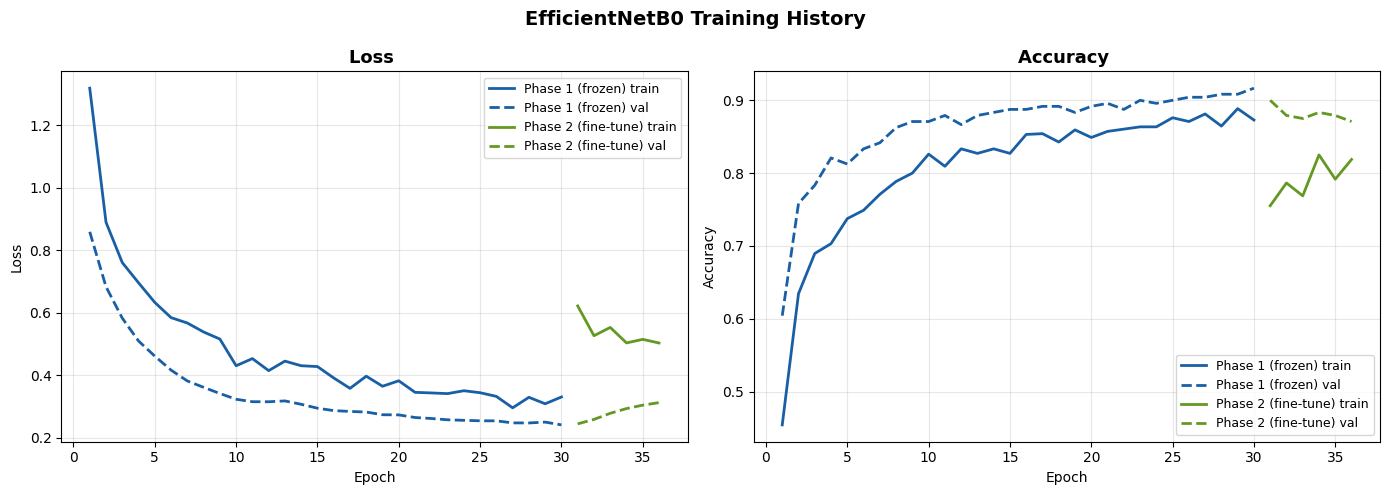

In [9]:
def plot_history(histories, labels, title_suffix=""):
    """Plot combined training curves from one or two history objects."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ["#185FA5", "#639922"]

    for ax_idx, metric in enumerate(["loss", "accuracy"]):
        ax = axes[ax_idx]
        offset = 0
        for hist, label, color in zip(histories, labels, colors):
            if hist is None:
                continue
            epochs = range(offset + 1, offset + len(hist.history[metric]) + 1)
            ax.plot(epochs, hist.history[metric],
                    label=f"{label} train", color=color, linewidth=2)
            val_key = f"val_{metric}"
            if val_key in hist.history:
                ax.plot(epochs, hist.history[val_key],
                        label=f"{label} val", color=color, linestyle="--", linewidth=2)
            offset += len(hist.history[metric])

        ax.set_title(f"{'Loss' if metric == 'loss' else 'Accuracy'} {title_suffix}",
                     fontsize=13, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric.capitalize())
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.suptitle(f"EfficientNetB0 Training History", fontsize=14, fontweight="bold")
    plt.tight_layout()
    hist_path = REPORTS_DIR / f"training_history_{TIMESTAMP}.png"
    fig.savefig(hist_path, dpi=150)
    print(f"Training history saved to: {hist_path}")
    plt.show()

histories_to_plot = [h for h in [history_initial, history_fine] if h is not None]
labels_to_plot    = ["Phase 1 (frozen)", "Phase 2 (fine-tune)"][:len(histories_to_plot)]
plot_history(histories_to_plot, labels_to_plot)


## Evaluation on Held-Out Test Set

Evaluate the final model on the test set — never seen during training or validation.
Produces classification report, confusion matrix, and per-class metric plots.


In [10]:
best_model = model
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f"\nTest loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

y_true, y_pred = [], []
for x_batch, y_batch in test_ds:
    probs = best_model.predict(x_batch, verbose=0)
    y_true.extend(np.argmax(y_batch.numpy(), axis=1).tolist())
    y_pred.extend(np.argmax(probs, axis=1).tolist())

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)

report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    output_dict=True,
    zero_division=0,
)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))
print(f"Macro precision: {macro_precision:.4f}")
print(f"Macro recall:    {macro_recall:.4f}")
print(f"Macro F1:        {macro_f1:.4f}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 235ms/step - accuracy: 0.8611 - loss: 0.5298

Test loss:     0.5298
Test accuracy: 0.8611

Classification Report:
              precision    recall  f1-score   support

    Overripe     0.9833    0.9833    0.9833        60
        Ripe     0.9487    0.6167    0.7475        60
   Underripe     0.7284    0.9833    0.8369        60

    accuracy                         0.8611       180
   macro avg     0.8868    0.8611    0.8559       180
weighted avg     0.8868    0.8611    0.8559       180

Macro precision: 0.8868
Macro recall:    0.8611
Macro F1:        0.8559


## Confusion Matrix and Per-Class Metrics

Saved confusion matrix: reports\confusion_matrix_20260423_160250.png


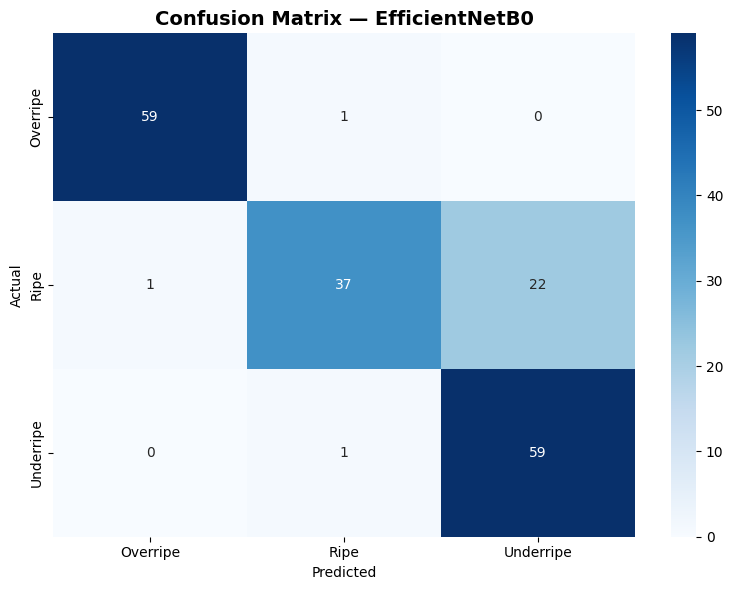

Saved metrics plot: reports\classification_metrics_20260423_160250.png


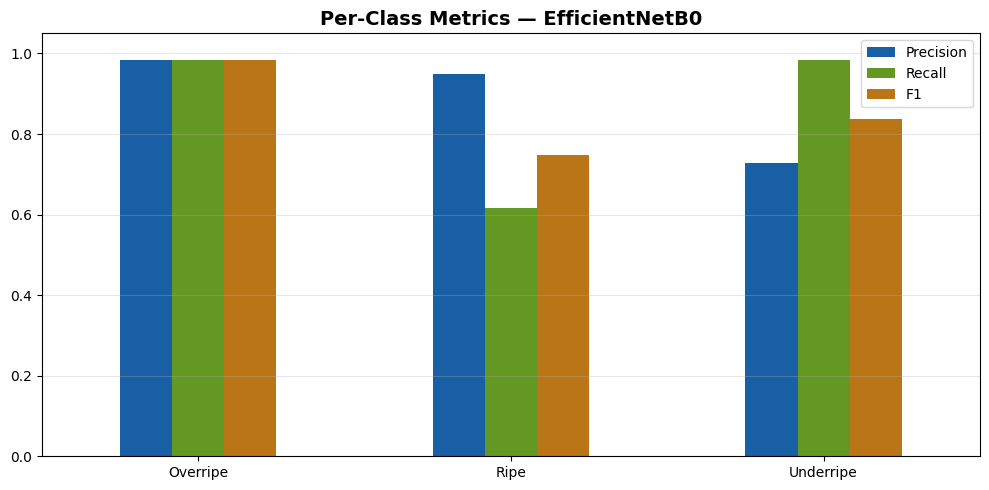

Saved Excel report: reports\classification_report_20260423_160250.xlsx


In [11]:
# ── Confusion matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax_cm
)
ax_cm.set_title("Confusion Matrix — EfficientNetB0", fontsize=14, fontweight="bold")
ax_cm.set_xlabel("Predicted")
ax_cm.set_ylabel("Actual")
plt.tight_layout()
fig_cm.savefig(CONFUSION_MATRIX_PATH, dpi=200)
print(f"Saved confusion matrix: {CONFUSION_MATRIX_PATH}")
plt.show()

# ── Per-class precision/recall/F1 bar chart ───────────────────────────────────
metric_rows = [label for label in CLASS_NAMES if label in report]
metric_df = pd.DataFrame(
    {
        "Precision": [report[label]["precision"] for label in metric_rows],
        "Recall":    [report[label]["recall"]    for label in metric_rows],
        "F1":        [report[label]["f1-score"]  for label in metric_rows],
    },
    index=metric_rows,
)

ax = metric_df.plot(kind="bar", figsize=(10, 5), color=["#185FA5", "#639922", "#BA7517"])
ax.set_title("Per-Class Metrics — EfficientNetB0", fontsize=14, fontweight="bold")
ax.set_ylim(0.0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(CLASSIFICATION_METRICS_PATH, dpi=200)
print(f"Saved metrics plot: {CLASSIFICATION_METRICS_PATH}")
plt.show()

# ── Excel export ──────────────────────────────────────────────────────────────
report_df   = pd.DataFrame(report).transpose()
confusion_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)

with pd.ExcelWriter(CLASSIFICATION_REPORT_XLSX) as writer:
    report_df.to_excel(writer,    sheet_name="classification_report")
    confusion_df.to_excel(writer, sheet_name="confusion_matrix")

print(f"Saved Excel report: {CLASSIFICATION_REPORT_XLSX}")


## Experiment Logging
Append one row to `reports/experiment_log_efficientnetb0.csv` for this run.

In [12]:
run_mode = "smoke_test" if DO_SMOKE else "full_train"
if DO_FINE_TUNE and not DO_SMOKE:
    run_mode = "full_train + fine_tune"

log_row = {
    "timestamp":            TIMESTAMP,
    "run_mode":             run_mode,
    "epochs_config":        EPOCHS,
    "fine_tune_epochs":     FINE_TUNE_EPOCHS if (DO_FINE_TUNE and not DO_SMOKE) else 0,
    "batch_size":           BATCH_SIZE,
    "val_split":            VAL_SPLIT,
    "initial_learning_rate": INITIAL_LR,
    "final_learning_rate":   FINE_TUNE_LR if (DO_FINE_TUNE and not DO_SMOKE) else INITIAL_LR,
    "backbone_unfrozen":    bool(DO_FINE_TUNE and not DO_SMOKE),
    "train_images":         TRAIN_IMAGE_COUNT,
    "test_images":          TEST_IMAGE_COUNT,
    "num_classes":          NUM_CLASSES,
    "accuracy":             round(float(test_acc), 4),
    "macro_precision":      round(float(macro_precision), 4),
    "macro_recall":         round(float(macro_recall), 4),
    "macro_f1":             round(float(macro_f1), 4),
    "best_model_file":      str(BEST_MODEL_PATH),
    "excel_report":         str(CLASSIFICATION_REPORT_XLSX),
    "notes": (
        f"model={MODEL_NAME}; preprocess_family={PREPROCESS_FAMILY}; "
        f"no_internal_preprocessing_layer=True; "
        f"fine_tune_unfreeze_layers={FINE_TUNE_UNFREEZE_LAYERS}"
    ),
}

log_df = pd.DataFrame([log_row])
if EXPERIMENT_LOG_PATH.exists():
    existing_df = pd.read_csv(EXPERIMENT_LOG_PATH)
    combined_df = pd.concat([existing_df, log_df], ignore_index=True)
else:
    combined_df = log_df

combined_df.to_csv(EXPERIMENT_LOG_PATH, index=False)
print("Experiment log updated:", EXPERIMENT_LOG_PATH)
print(f"  Run: {run_mode} | Acc: {test_acc:.4f} | F1: {macro_f1:.4f}")
combined_df.tail(5)


Experiment log updated: reports\experiment_log_efficientnetb0.csv
  Run: full_train + fine_tune | Acc: 0.8611 | F1: 0.8559


,timestamp,run_mode,epochs_config,fine_tune_epochs,batch_size,val_split,initial_learning_rate,final_learning_rate,backbone_unfrozen,train_images,test_images,num_classes,accuracy,macro_precision,macro_recall,macro_f1,best_model_file,excel_report,notes
0,20260423_160250,full_train + fine_tune,30,15,32,0.2,0.0001,0.00001,True,1200,180,3,0.8611,0.8868,0.8611,0.8559,saved_models\palm_ripeness_best_20260423_16025...,reports\classification_report_20260423_160250....,model=EfficientNetB0; preprocess_family=effici...


## TFLite Conversion (Notebook In-Memory Path)

Convert the live in-memory model directly to FP32 / FP16 / INT8 TFLite artifacts.

This path avoids the Keras 3 H5 deserialization issue encountered with MobileNetV3.
The model in memory is used directly — no reload from disk.

**Note**: After running this cell, register `"efficientnet"` as a supported
`PREPROCESS_FAMILY` in `scripts/pi_inference.py` and `scripts/convert_tflite.py`
before deploying to the Pi runtime.


In [13]:
PROJECT_ROOT       = Path.cwd().parent
OUTPUT_MODELS_DIR  = PROJECT_ROOT / "models"
OUTPUT_MODELS_DIR.mkdir(parents=True, exist_ok=True)

CONVERT_TS    = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
BASE_NAME     = OUTPUT_MODELS_DIR / f"palm_ripeness_best_{CONVERT_TS}"
LABELS_PATH   = OUTPUT_MODELS_DIR / f"labels_{CONVERT_TS}.json"
MANIFEST_PATH = OUTPUT_MODELS_DIR / f"tflite_manifest_{CONVERT_TS}.json"

# Write labels file
with open(LABELS_PATH, "w", encoding="utf-8") as f:
    json.dump(CLASS_NAMES, f, ensure_ascii=False, indent=2)
print("Labels saved:", LABELS_PATH)


def rep_dataset_gen(data_dir: Path, img_size=(224, 224), take=500, seed=42):
    """
    Deterministic balanced representative dataset for INT8 PTQ calibration.
    Samples equally from each class folder (seed-fixed shuffle).
    """
    random.seed(seed)
    class_dirs = sorted([d for d in data_dir.iterdir() if d.is_dir()])
    n_per_class = max(1, take // len(class_dirs))

    sampled = []
    for cls_dir in class_dirs:
        files = sorted([
            p for p in cls_dir.iterdir()
            if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
        ])
        random.shuffle(files)
        sampled.extend(files[:n_per_class])
    random.shuffle(sampled)

    print(f"[Calibration] {len(sampled)} images from {len(class_dirs)} classes")

    def _gen():
        for path in sampled:
            img = tf.io.read_file(str(path))
            img = tf.image.decode_image(img, channels=3)
            img.set_shape([None, None, 3])
            img = tf.image.resize(img, img_size)
            img = apply_preprocess(img)
            yield [tf.expand_dims(img, 0)]

    return _gen


# ── FP32 ──────────────────────────────────────────────────────────────────────
print("\nConverting FP32...")
converter_fp32 = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_fp32    = converter_fp32.convert()
FP32_PATH      = str(BASE_NAME) + "_fp32.tflite"
with open(FP32_PATH, "wb") as f:
    f.write(tflite_fp32)
print(f"FP32 saved: {FP32_PATH} ({len(tflite_fp32)/1024/1024:.2f} MB)")

# ── FP16 ──────────────────────────────────────────────────────────────────────
print("\nConverting FP16...")
converter_fp16 = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter_fp16.optimizations = [tf.lite.Optimize.DEFAULT]
converter_fp16.target_spec.supported_types = [tf.float16]
tflite_fp16    = converter_fp16.convert()
FP16_PATH      = str(BASE_NAME) + "_float16.tflite"
with open(FP16_PATH, "wb") as f:
    f.write(tflite_fp16)
print(f"FP16 saved: {FP16_PATH} ({len(tflite_fp16)/1024/1024:.2f} MB)")

# ── INT8 PTQ ──────────────────────────────────────────────────────────────────
print("\nConverting INT8 (PTQ, 500 balanced calibration images)...")
converter_int8 = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = rep_dataset_gen(TRAIN_ROOT, IMG_SIZE, take=500, seed=42)
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type  = tf.float32   # float I/O for pipeline compatibility
converter_int8.inference_output_type = tf.float32
converter_int8.experimental_new_quantizer = True
tflite_int8    = converter_int8.convert()
INT8_PATH      = str(BASE_NAME) + "_int8.tflite"
with open(INT8_PATH, "wb") as f:
    f.write(tflite_int8)
print(f"INT8 saved: {INT8_PATH} ({len(tflite_int8)/1024/1024:.2f} MB)")

# ── Manifest ──────────────────────────────────────────────────────────────────
manifest = {
    "timestamp":       CONVERT_TS,
    "source":          "notebook_inMemory_conversion",
    "source_h5":       str((Path.cwd() / BEST_MODEL_PATH).resolve()),
    "labels":          str(LABELS_PATH.resolve()),
    "img_size":        IMG_SIZE[0],
    "preprocess_family": PREPROCESS_FAMILY,
    "class_names":     CLASS_NAMES,
    "artifacts": {
        "fp32":    str(Path(FP32_PATH).resolve()),
        "float16": str(Path(FP16_PATH).resolve()),
        "int8":    str(Path(INT8_PATH).resolve()),
    },
}
with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

print("\nManifest saved:", MANIFEST_PATH)
print("\nConversion complete. Summary:")
print(f"  FP32:  {Path(FP32_PATH).name}  ({len(tflite_fp32)/1024/1024:.2f} MB)")
print(f"  FP16:  {Path(FP16_PATH).name}  ({len(tflite_fp16)/1024/1024:.2f} MB)")
print(f"  INT8:  {Path(INT8_PATH).name}  ({len(tflite_int8)/1024/1024:.2f} MB)")


Labels saved: c:\Users\jeffy\Documents\PSM\Project Coding\PSM_PalmFruitRipenessClassificationSystem\models\labels_20260423_161024.json

Converting FP32...
INFO:tensorflow:Assets written to: C:\Users\jeffy\AppData\Local\Temp\tmp6wv_o9k9\assets


INFO:tensorflow:Assets written to: C:\Users\jeffy\AppData\Local\Temp\tmp6wv_o9k9\assets


Saved artifact at 'C:\Users\jeffy\AppData\Local\Temp\tmp6wv_o9k9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1577406114960: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  1577406113616: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  1577402293840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1577402293456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1577402296336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1577402298256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1577402300368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1577402297104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1577402300176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1577402293648: TensorSpec(shape=(), dtype=tf.resource, name=No

INFO:tensorflow:Assets written to: C:\Users\jeffy\AppData\Local\Temp\tmphdoo508x\assets


Saved artifact at 'C:\Users\jeffy\AppData\Local\Temp\tmphdoo508x'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1577406114960: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  1577406113616: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  1577402293840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1577402293456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1577402296336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1577402298256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1577402300368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1577402297104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1577402300176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1577402293648: TensorSpec(shape=(), dtype=tf.resource, name=No

INFO:tensorflow:Assets written to: C:\Users\jeffy\AppData\Local\Temp\tmpaf7lv97_\assets


Saved artifact at 'C:\Users\jeffy\AppData\Local\Temp\tmpaf7lv97_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1577406114960: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  1577406113616: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  1577402293840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1577402293456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1577402296336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1577402298256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1577402300368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1577402297104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1577402300176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1577402293648: TensorSpec(shape=(), dtype=tf.resource, name=No

C:\Users\jeffy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INT8 saved: c:\Users\jeffy\Documents\PSM\Project Coding\PSM_PalmFruitRipenessClassificationSystem\models\palm_ripeness_best_20260423_161024_int8.tflite (4.84 MB)

Manifest saved: c:\Users\jeffy\Documents\PSM\Project Coding\PSM_PalmFruitRipenessClassificationSystem\models\tflite_manifest_20260423_161024.json

Conversion complete. Summary:
  FP32:  palm_ripeness_best_20260423_161024_fp32.tflite  (15.92 MB)
  FP16:  palm_ripeness_best_20260423_161024_float16.tflite  (8.02 MB)
  INT8:  palm_ripeness_best_20260423_161024_int8.tflite  (4.84 MB)


## Next Step Commands

### 1. Validate FP32 vs INT8 accuracy drop
```bash
python scripts/validate_tflite.py \
  --model-fp32 models/palm_ripeness_best_<CONVERT_TS>_fp32.tflite \
  --model-int8 models/palm_ripeness_best_<CONVERT_TS>_int8.tflite \
  --labels models/labels_<CONVERT_TS>.json \
  --data-dir C:/Users/jeffy/Documents/PSM/Dataset1/Test \
  --img-size 224 \
  --preprocess-family efficientnet
```
Pass gate: relative INT8 drop < 2%

### 2. Register `efficientnet` preprocessing family in runtime scripts
Before running the Pi or API, add `efficientnet` support to:
- `scripts/pi_inference.py` — add branch in `_preprocess_image()`
- `scripts/convert_tflite.py` — add branch in `apply_preprocess()`

Pattern to add (mirrors the existing `mobilenet_v3` branch):
```python
elif preprocess_family == "efficientnet":
    from tensorflow.keras.applications.efficientnet import preprocess_input
    return preprocess_input(x.astype("float32"))
```

### 3. API smoke test
```bash
MODEL_PATH=models/palm_ripeness_best_<CONVERT_TS>_fp32.tflite \
LABELS_PATH=models/labels_<CONVERT_TS>.json \
python api/app.py
```
```bash
curl http://127.0.0.1:5000/health
curl -X POST -F "file=@<sample_image>.jpg" http://127.0.0.1:5000/classify
```

### 4. CLI latency benchmark (run on Pi)
```bash
python scripts/pi_inference.py \
  --model models/palm_ripeness_best_<CONVERT_TS>_int8.tflite \
  --labels models/labels_<CONVERT_TS>.json \
  --image <sample_image>.jpg \
  --warmup 1 \
  --runs 10
```

### 5. Update Model.md section 8.1 with measured results
After validation, fill in:
- EfficientNetB0 accuracy, macro F1, INT8 accuracy, INT8 drop, INT8 size, Pi latency
